<a href="https://colab.research.google.com/github/ramjotkaur0927-ops/DecodelabsInternship-Project-2/blob/main/Decodelabs_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
df= pd.read_excel('/content/Dataset for Data Analytics.xlsx')

In [3]:
print(df.shape)

(1200, 14)


In [4]:
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [5]:
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64
0


Coupon Code has 309 missing values (25.75%). This is expected- orders placed without a coupon. All other columns are complete.


In [6]:
df[['Quantity','UnitPrice','TotalPrice','ItemsInCart']].describe().round(2)

,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,1053.97,5.48
std,1.41,197.18,819.86,2.28
min,1.00,11.39,11.39,1.00
25%,2.00,186.06,410.52,4.00
50%,3.00,364.21,823.62,5.00
75%,4.00,521.57,1578.48,7.00
max,5.00,699.93,3456.40,10.00


In [7]:
mean_price= df['TotalPrice'].mean()
median_price= df['TotalPrice'].median()
skew_price= df['TotalPrice'].skew()

print("Mean TotalPrice :", mean_price)
print("Median TotalPrice :", median_price)
print("skewness:", skew_price)

Mean TotalPrice : 1053.9683
Median TotalPrice : 823.615
skewness: 0.8913590826809059


Mean(1053.97)> Median(823.62) - data is right skewed. A few large bulk orders pull the average up. Median is the true center.

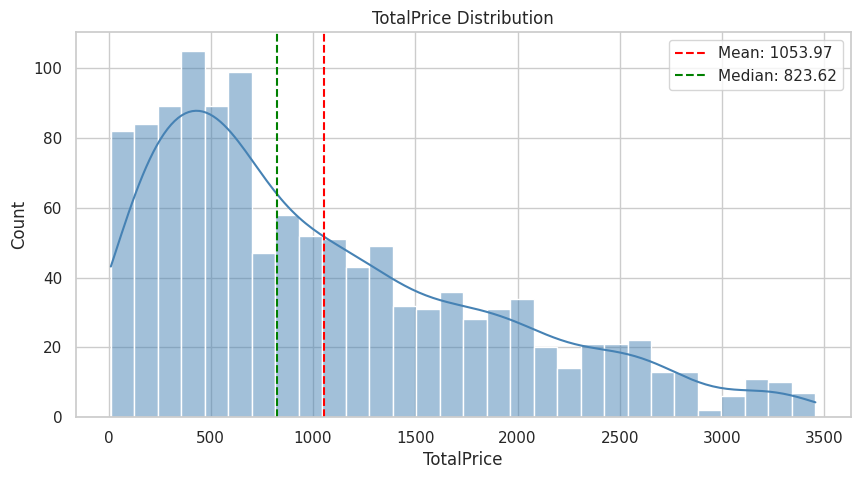

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['TotalPrice'], bins=30, kde=True, color='steelblue')
plt.axvline(df['TotalPrice'].mean(), color='red', linestyle='--', label='Mean: 1053.97')
plt.axvline(df['TotalPrice'].median(), color='green', linestyle='--', label='Median: 823.62')
plt.title('TotalPrice Distribution')
plt.legend()
plt.show()

In [9]:
print(df['Product'].value_counts())
print(df['OrderStatus'].value_counts())
print(df['ReferralSource'].value_counts())
print(df['PaymentMethod'].value_counts())

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


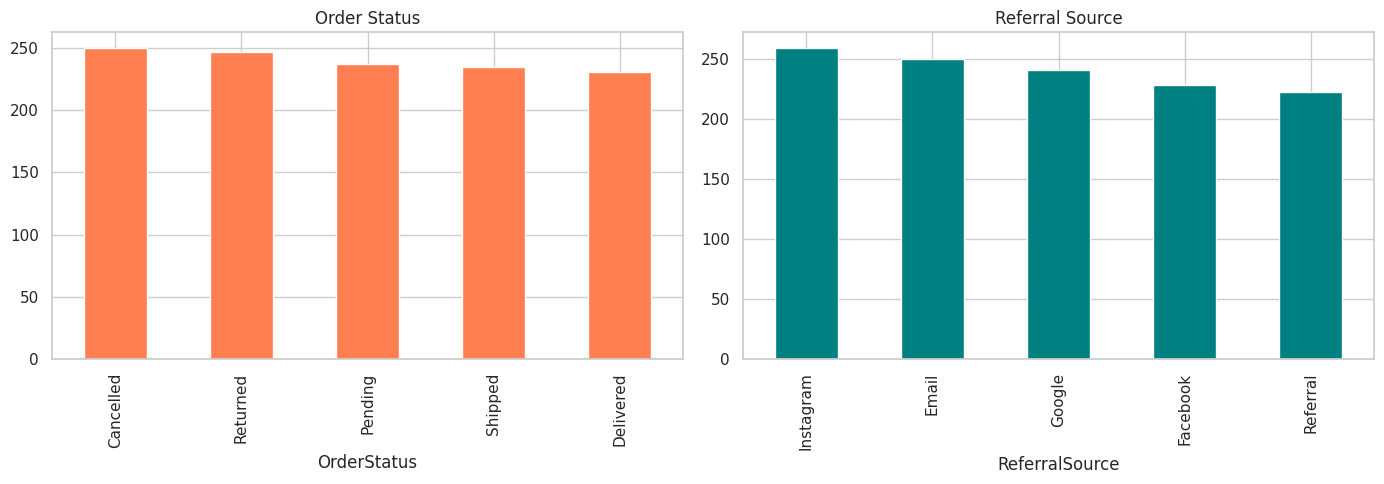

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df['OrderStatus'].value_counts().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Order Status')

df['ReferralSource'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Referral Source')

plt.tight_layout()
plt.show()


Cancelled(250) + Returned(247) = 497 orders = 41.4% lost revenue. Instagram is the top referral source.

In [11]:

Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Bound:", upper)

outliers = df[df['TotalPrice'] > upper]
print("Outlier count:", len(outliers))
print(outliers[['OrderID','Product','Quantity','UnitPrice','TotalPrice']])

Q1: 410.52
Q3: 1578.475
IQR: 1167.955
Upper Bound: 3330.4075
Outlier count: 8
        OrderID  Product  Quantity  UnitPrice  TotalPrice
107   ORD200107  Printer         5     670.75     3353.75
326   ORD200326   Laptop         5     670.48     3352.40
328   ORD200328   Tablet         5     674.04     3370.20
469   ORD200469    Chair         5     676.98     3384.90
632   ORD200632   Laptop         5     678.16     3390.80
789   ORD200789   Tablet         5     691.28     3456.40
1065  ORD201065  Printer         5     666.80     3334.00
1122  ORD201122  Monitor         5     678.19     3390.95


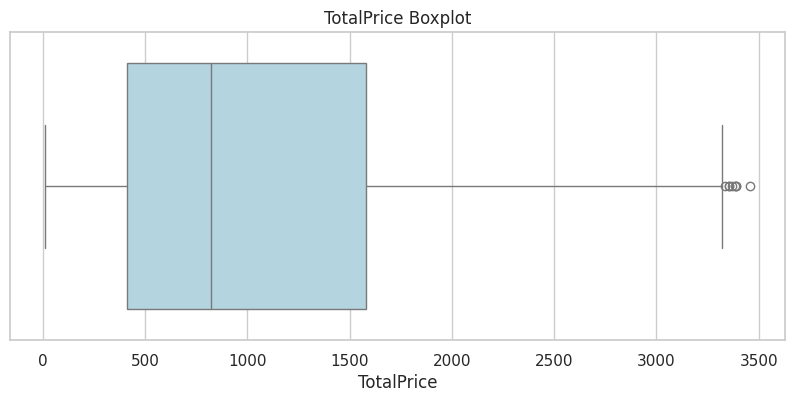

In [12]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['TotalPrice'], color='lightblue')
plt.title('TotalPrice Boxplot')
plt.show()

8 outliners found. All have Quantity= 5 and high UnitPrice. These are genuine bulk orders, not errors- treat as VIP customers.

             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity         1.00       0.01        0.62         0.65
UnitPrice        0.01       1.00        0.72         0.00
TotalPrice       0.62       0.72        1.00         0.39
ItemsInCart      0.65       0.00        0.39         1.00


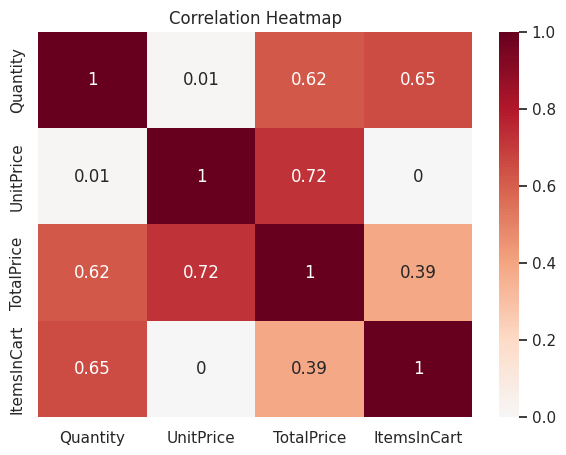

In [13]:
corr = df[['Quantity','UnitPrice','TotalPrice','ItemsInCart']].corr().round(2)
print(corr)

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.show()

UnitPrice vs TotalPrice= 0.72(strong). Quantity vs TotalPrice= 0.62(strong). Both independently drive order value.

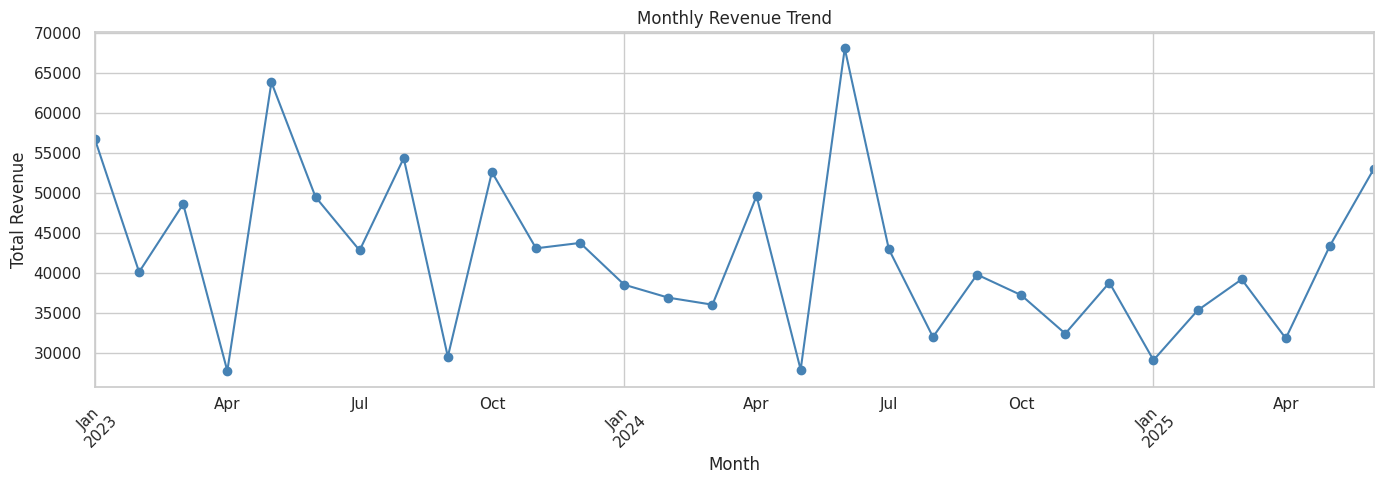

Best month: 2024-06 68068.54000000001
Worst month: 2023-04 27751.71


In [14]:
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(14,5))
monthly.plot(marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

print("Best month:", monthly.idxmax(), monthly.max())
print("Worst month:", monthly.idxmin(), monthly.min())

Peak: June 2024(₹68,068). Lowest: May 2024(₹27,909). Revenue is volatile -- likely campaign- driven, not seasonal.

In [15]:
print(df.groupby('Product')['TotalPrice'].mean().round(2).sort_values(ascending=False))

df['HasCoupon'] = df['CouponCode'].notna()
print(df.groupby('HasCoupon')['TotalPrice'].mean().round(2))

Product
Laptop     1110.56
Chair      1098.99
Printer    1080.73
Monitor    1077.62
Tablet     1042.28
Desk        985.06
Phone       972.58
Name: TotalPrice, dtype: float64
HasCoupon
False    1043.37
True     1057.64
Name: TotalPrice, dtype: float64


Laptop has highest avg order value(₹1,110). Coupon users spend only ₹14 more than non- coupon users-- coupons have minimal impact.

**Key Observations:**

1.**Data Quality** — Only CouponCode has missing values (309 rows, 25.75%). All other columns are 100% complete.


2.**Distribution** — TotalPrice is right-skewed (Mean ₹1053.97 > Median ₹823.62). Median is the true center of order value.


3.**Order Status** — 41.4% of orders are either Cancelled or Returned — a major revenue loss risk.


4.**Top Referral Source** — Instagram drives the most orders (259), followed by Email (250).


5.**Outliers** — 8 bulk orders exceed the IQR upper bound. All have Quantity=5 and high UnitPrice — genuine VIP buyers, not errors.

  
6.**Correlation** — UnitPrice (r=0.72) and Quantity (r=0.62) are the strongest drivers of TotalPrice.

  
7.**Revenue Trend** — Peak month was June 2024 (₹68,068). Revenue is volatile, suggesting campaign-driven sales.

  
8.**Coupon Impact** — Coupon users spend only ₹14 more than non-coupon users — minimal impact.